In [6]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed set to:", SEED)

Random seed set to: 42


In [7]:
import os

os.makedirs("/kaggle/working/Figures", exist_ok=True)

In [8]:
(train_raw, val_raw, test_raw), ds_info = tfds.load(
    "oxford_iiit_pet",
    split=["train[:80%]", "train[80%:]", "test"],
    as_supervised=True,
    with_info=True
)

print("Dataset loaded successfully.")

print("Number of classes:", ds_info.features["label"].num_classes)
print("Class names:")
print(ds_info.features["label"].names)

print("Training samples  :", tf.data.experimental.cardinality(train_raw).numpy())
print("Validation samples:", tf.data.experimental.cardinality(val_raw).numpy())
print("Test samples      :", tf.data.experimental.cardinality(test_raw).numpy())

Dataset loaded successfully.
Number of classes: 37
Class names:
['Abyssinian', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle', 'Bengal', 'Birman', 'Bombay', 'boxer', 'British_Shorthair', 'chihuahua', 'Egyptian_Mau', 'english_cocker_spaniel', 'english_setter', 'german_shorthaired', 'great_pyrenees', 'havanese', 'japanese_chin', 'keeshond', 'leonberger', 'Maine_Coon', 'miniature_pinscher', 'newfoundland', 'Persian', 'pomeranian', 'pug', 'Ragdoll', 'Russian_Blue', 'saint_bernard', 'samoyed', 'scottish_terrier', 'shiba_inu', 'Siamese', 'Sphynx', 'staffordshire_bull_terrier', 'wheaten_terrier', 'yorkshire_terrier']
Training samples  : 2944
Validation samples: 736
Test samples      : 3669


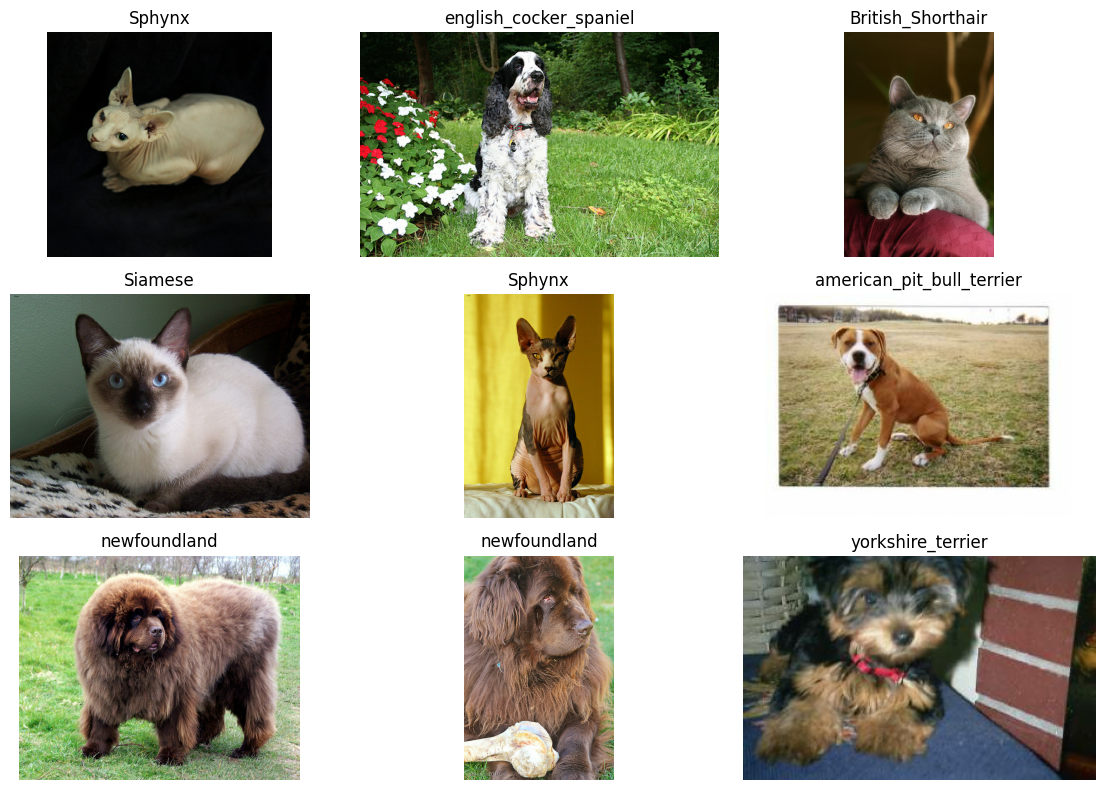

In [9]:
plt.figure(figsize=(12, 8))

for i, (image, label) in enumerate(train_raw.take(9)):
    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(ds_info.features["label"].names[label.numpy()])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
IMG_SIZE = (224, 224)

def preprocess_image(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = preprocess_input(image)
    return image, label

train_data = train_raw.map(
    preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_data = val_raw.map(
    preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_data = test_raw.map(
    preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

In [11]:
BATCH_SIZE = 32

train_data = train_data.shuffle(
    1000,
    seed=SEED,
    reshuffle_each_iteration=True
)

train_data = train_data.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_data = val_data.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_data = test_data.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [12]:
for images, labels in train_data.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Image data type:", images.dtype)
    print("Label data type:", labels.dtype)

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Image data type: <dtype: 'float32'>
Label data type: <dtype: 'int64'>


In [13]:
# ============================================================
# PART 3 — BASELINE MOBILENETV2
# ============================================================

NUM_CLASSES = 37
LEARNING_RATE = 0.001

# Load pretrained MobileNetV2
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze the pretrained base
base_model.trainable = False

# Build classifier
inputs = keras.Input(shape=(224, 224, 3))

x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

baseline_model = keras.Model(inputs, outputs)

# Compile model
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 37)             │        47,397 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,305,381 (8.79 MB)

 Trainable params: 47,397 (185.14 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [14]:
EPOCHS = 5

start_time = time.time()

baseline_history = baseline_model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS
)

baseline_time = time.time() - start_time

print(f"\nBaseline training time: {baseline_time:.2f} seconds")

Epoch 1/5


2026-08-24 15:26:38.578987: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-24 15:26:38.715501: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1787585200.466674     159 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


92/92 ━━━━━━━━━━━━━━━━━━━━ 29s 98ms/step - accuracy: 0.6895 - loss: 1.3035 - val_accuracy: 0.8696 - val_loss: 0.5039
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.9351 - loss: 0.3093 - val_accuracy: 0.8954 - val_loss: 0.3769
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.9592 - loss: 0.1948 - val_accuracy: 0.8927 - val_loss: 0.3412
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.9769 - loss: 0.1353 - val_accuracy: 0.9008 - val_loss: 0.3144
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.9912 - loss: 0.0976 - val_accuracy: 0.8954 - val_loss: 0.3057

Baseline training time: 52.72 seconds


In [15]:
baseline_val_loss, baseline_val_accuracy = baseline_model.evaluate(
    val_data,
    verbose=1
)

print(f"Baseline Validation Loss     : {baseline_val_loss:.4f}")
print(f"Baseline Validation Accuracy : {baseline_val_accuracy * 100:.2f}%")

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.8954 - loss: 0.3057
Baseline Validation Loss     : 0.3057
Baseline Validation Accuracy : 89.54%


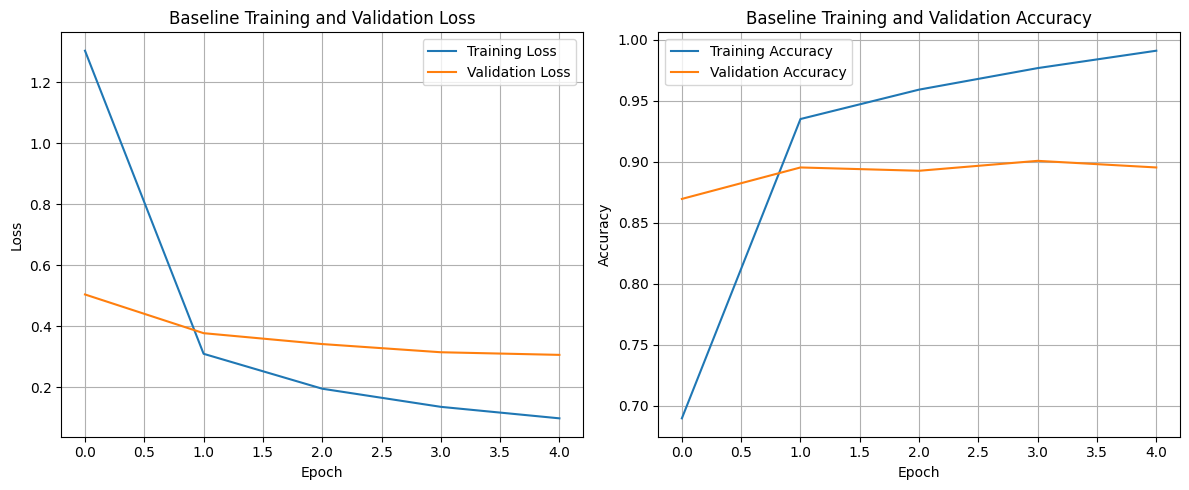

Model                  Baseline MobileNetV2
Validation Accuracy               89.538044
Validation Loss                    0.305746
Training Time (s)                 52.719244
Parameters                          2305381
dtype: object


In [16]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.plot(
    baseline_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    baseline_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)

plt.plot(
    baseline_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    baseline_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

baseline_results = {
    "Model": "Baseline MobileNetV2",
    "Validation Accuracy": baseline_val_accuracy * 100,
    "Validation Loss": baseline_val_loss,
    "Training Time (s)": baseline_time,
    "Parameters": baseline_model.count_params()
}

print(pd.Series(baseline_results))

In [17]:
# ============================================================
# PART 4 — WEIGHT INITIALIZATION
# ============================================================

def build_initialization_model(initializer):

    # Load pretrained MobileNetV2
    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    # Freeze pretrained layers
    base_model.trainable = False

    # Input
    inputs = keras.Input(shape=(224, 224, 3))

    # Feature extraction
    x = base_model(inputs, training=False)

    # Global Average Pooling
    x = layers.GlobalAveragePooling2D()(x)

    # Classifier with selected initialization
    outputs = layers.Dense(
        37,
        activation="softmax",
        kernel_initializer=initializer
    )(x)

    model = keras.Model(inputs, outputs)

    # Same optimizer for every experiment
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [18]:
initializers_dict = {
    "Zero": keras.initializers.Zeros(),

    "Random": keras.initializers.RandomNormal(
        mean=0.0,
        stddev=0.05
    ),

    "Xavier/Glorot": keras.initializers.GlorotUniform(),

    "He": keras.initializers.HeNormal()
}

print("Initialization methods:")
for name in initializers_dict:
    print("-", name)

Initialization methods:
- Zero
- Random
- Xavier/Glorot
- He


In [19]:
initialization_histories = {}
initialization_times = {}
initialization_models = {}

EPOCHS = 5

for name, initializer in initializers_dict.items():

    print("\n" + "=" * 60)
    print(f"Training with {name} initialization")
    print("=" * 60)

    # Build model
    model = build_initialization_model(initializer)

    # Record training time
    start_time = time.time()

    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=EPOCHS,
        verbose=1
    )

    training_time = time.time() - start_time

    # Store results
    initialization_histories[name] = history
    initialization_times[name] = training_time
    initialization_models[name] = model

    print(f"{name} training time: {training_time:.2f} seconds")


Training with Zero initialization
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 99ms/step - accuracy: 0.7714 - loss: 1.1425 - val_accuracy: 0.9022 - val_loss: 0.4328
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.9426 - loss: 0.2850 - val_accuracy: 0.9117 - val_loss: 0.3539
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.9660 - loss: 0.1807 - val_accuracy: 0.9130 - val_loss: 0.3076
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.9813 - loss: 0.1258 - val_accuracy: 0.9130 - val_loss: 0.2876
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.9925 - loss: 0.0905 - val_accuracy: 0.9130 - val_loss: 0.2770
Zero training time: 41.96 seconds

Training with Random initialization
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 97ms/step - accuracy: 0.6450 - loss: 1.4027 - val_accuracy: 0.8696 - val_loss: 0.5235
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.9178 - loss: 0.3393 - val_accuracy: 0.8995 - val_loss: 0.3646
Epoch 3/5


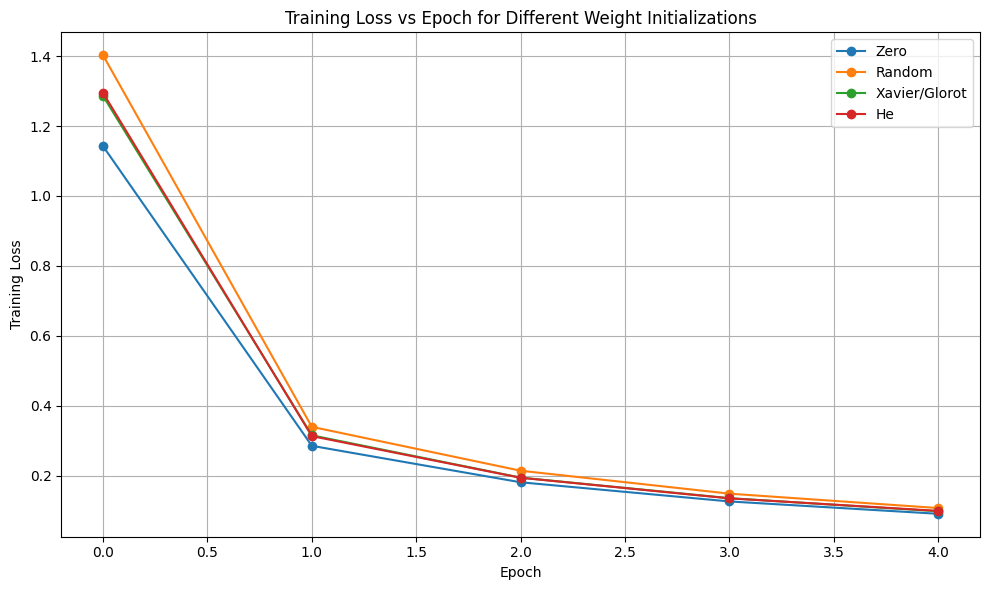

In [20]:
plt.figure(figsize=(10, 6))

for name, history in initialization_histories.items():

    plt.plot(
        history.history["loss"],
        marker="o",
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epoch for Different Weight Initializations")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(
    "Figures/plot_1_training_loss_initialization.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

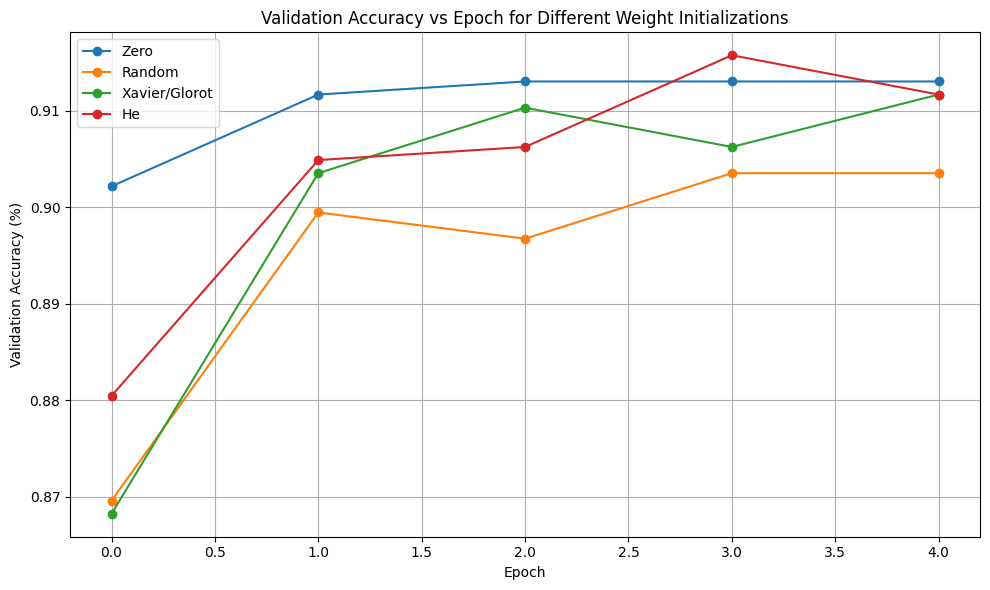

In [21]:
plt.figure(figsize=(10, 6))

for name, history in initialization_histories.items():

    plt.plot(
        history.history["val_accuracy"],
        marker="o",
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Validation Accuracy vs Epoch for Different Weight Initializations")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(
    "Figures/plot_2_validation_accuracy_initialization.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [22]:
initialization_results = []

for name, history in initialization_histories.items():

    final_loss = history.history["loss"][-1]
    best_val_accuracy = max(history.history["val_accuracy"]) * 100

    initialization_results.append({
        "Initialization": name,
        "Final Training Loss": final_loss,
        "Best Validation Accuracy (%)": best_val_accuracy,
        "Training Time (s)": initialization_times[name]
    })

initialization_results_df = pd.DataFrame(initialization_results)

initialization_results_df

best_initialization = initialization_results_df.loc[
    initialization_results_df["Best Validation Accuracy (%)"].idxmax(),
    "Initialization"
]

print("Best initialization:", best_initialization)

Best initialization: He


In [23]:
# ============================================================
# PART 5 — REGULARIZATION
# ============================================================

def build_regularization_model(
    regularization_type="none",
    dropout_rate=0.5,
    l2_rate=0.001
):

    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    base_model.trainable = False

    inputs = keras.Input(shape=(224, 224, 3))

    x = base_model(inputs, training=False)

    # Batch Normalization
    if regularization_type == "batch_norm":
        x = layers.BatchNormalization()(x)

    x = layers.GlobalAveragePooling2D()(x)

    # L2 regularization
    if regularization_type == "l2":
        x = layers.Dense(
            128,
            activation="relu",
            kernel_regularizer=regularizers.l2(l2_rate)
        )(x)

    else:
        x = layers.Dense(
            128,
            activation="relu"
        )(x)

    # Dropout
    if regularization_type == "dropout":
        x = layers.Dropout(dropout_rate)(x)

    # Output layer
    outputs = layers.Dense(
        37,
        activation="softmax"
    )(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [24]:
regularization_configs = {
    "No Regularization": {
        "regularization_type": "none"
    },

    "L2 Regularization": {
        "regularization_type": "l2",
        "l2_rate": 0.001
    },

    "Dropout": {
        "regularization_type": "dropout",
        "dropout_rate": 0.5
    },

    "Batch Normalization": {
        "regularization_type": "batch_norm"
    }
}

In [25]:
regularization_histories = {}
regularization_times = {}
regularization_models = {}

EPOCHS = 5

for name, config in regularization_configs.items():

    print("\n" + "=" * 60)
    print(f"Training: {name}")
    print("=" * 60)

    model = build_regularization_model(**config)

    start_time = time.time()

    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=EPOCHS,
        verbose=1
    )

    training_time = time.time() - start_time

    regularization_histories[name] = history
    regularization_times[name] = training_time
    regularization_models[name] = model

    print(f"Training time: {training_time:.2f} seconds")


Training: No Regularization
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 100ms/step - accuracy: 0.7554 - loss: 0.9887 - val_accuracy: 0.8899 - val_loss: 0.3514
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.9378 - loss: 0.2113 - val_accuracy: 0.9008 - val_loss: 0.3128
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.9633 - loss: 0.1157 - val_accuracy: 0.8967 - val_loss: 0.3240
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.9901 - loss: 0.0597 - val_accuracy: 0.9008 - val_loss: 0.3076
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.9973 - loss: 0.0322 - val_accuracy: 0.9049 - val_loss: 0.3136
Training time: 42.77 seconds

Training: L2 Regularization
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 99ms/step - accuracy: 0.7266 - loss: 1.3357 - val_accuracy: 0.8791 - val_loss: 0.6625
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.9358 - loss: 0.4519 - val_accuracy: 0.9022 - val_loss: 0.5645
Epoch 3/5
92/92 ━━━━━━━━━━━━

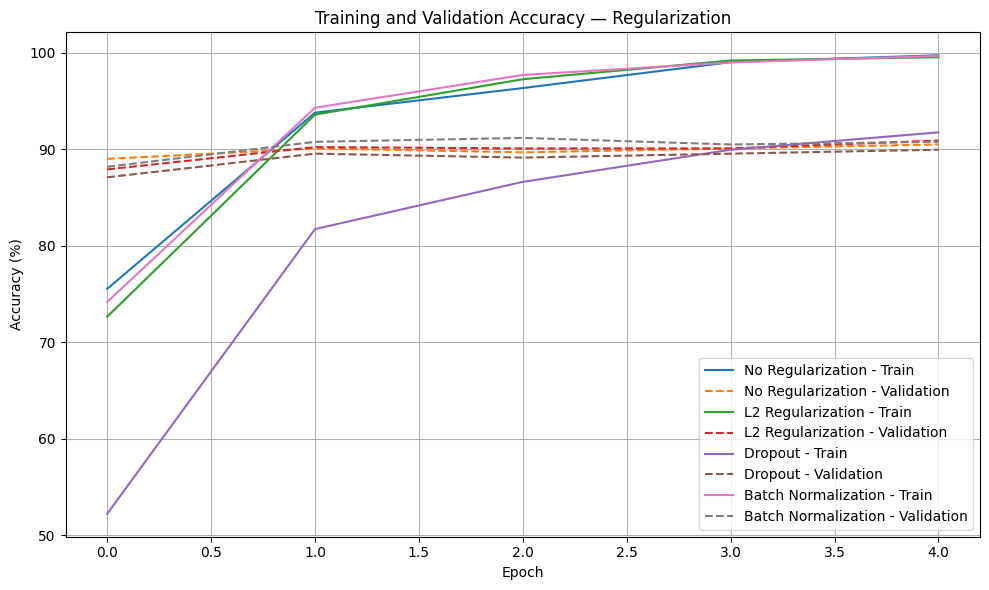

In [26]:
# Plot 3 — Training and Validation Accuracy

plt.figure(figsize=(10, 6))

for name, history in regularization_histories.items():

    plt.plot(
        np.array(history.history["accuracy"]) * 100,
        label=f"{name} - Train"
    )

    plt.plot(
        np.array(history.history["val_accuracy"]) * 100,
        linestyle="--",
        label=f"{name} - Validation"
    )

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy — Regularization")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(
    "Figures/plot_3_regularization_accuracy.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

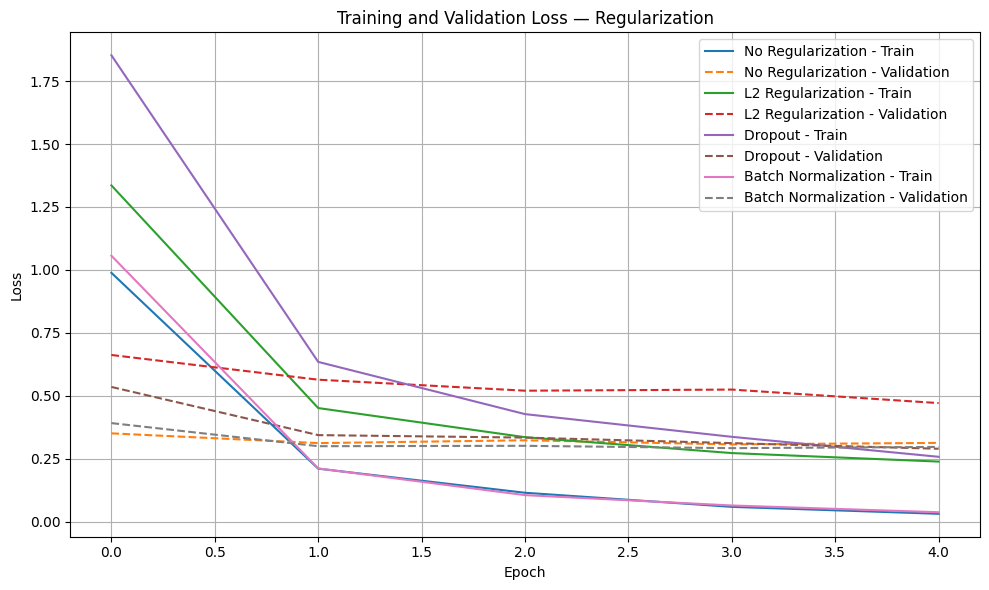

In [27]:
# Plot 4 — Training and Validation Loss

plt.figure(figsize=(10, 6))

for name, history in regularization_histories.items():

    plt.plot(
        history.history["loss"],
        label=f"{name} - Train"
    )

    plt.plot(
        history.history["val_loss"],
        linestyle="--",
        label=f"{name} - Validation"
    )

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss — Regularization")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(
    "Figures/plot_4_regularization_loss.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [28]:
regularization_results = []

for name, history in regularization_histories.items():

    regularization_results.append({
        "Regularization": name,
        "Final Training Loss":
            history.history["loss"][-1],
        "Best Validation Accuracy (%)":
            max(history.history["val_accuracy"]) * 100,
        "Training Time (s)":
            regularization_times[name]
    })

regularization_results_df = pd.DataFrame(
    regularization_results
)

regularization_results_df

,Regularization,Final Training Loss,Best Validation Accuracy (%),Training Time (s)
0,No Regularization,0.032160,90.489131,42.766963
1,L2 Regularization,0.239413,90.896738,42.484357
2,Dropout,0.258408,89.945650,44.184877
3,Batch Normalization,0.038386,91.168481,42.656995


In [29]:
# ============================================================
# PART 6 — BATCH NORMALIZATION
# ============================================================

def build_bn_model(use_bn=True):

    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    base_model.trainable = False

    inputs = keras.Input(shape=(224, 224, 3))

    x = base_model(inputs, training=False)

    x = layers.GlobalAveragePooling2D()(x)

    if use_bn:
        x = layers.BatchNormalization()(x)

    x = layers.Dense(
        128,
        activation="relu"
    )(x)

    outputs = layers.Dense(
        37,
        activation="softmax"
    )(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [30]:
bn_histories = {}

for name, use_bn in {
    "Without BN": False,
    "With BN": True
}.items():

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    model = build_bn_model(use_bn)

    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=EPOCHS,
        verbose=1
    )

    bn_histories[name] = history


Without BN
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 99ms/step - accuracy: 0.7215 - loss: 1.0889 - val_accuracy: 0.8845 - val_loss: 0.4089
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.9406 - loss: 0.2071 - val_accuracy: 0.8967 - val_loss: 0.3385
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.9674 - loss: 0.1168 - val_accuracy: 0.8995 - val_loss: 0.3190
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.9881 - loss: 0.0624 - val_accuracy: 0.9062 - val_loss: 0.2851
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.9973 - loss: 0.0340 - val_accuracy: 0.9035 - val_loss: 0.3014

With BN
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 100ms/step - accuracy: 0.7432 - loss: 0.9110 - val_accuracy: 0.8614 - val_loss: 0.5035
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.9555 - loss: 0.1552 - val_accuracy: 0.8913 - val_loss: 0.3441
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.9878 - loss: 0.0632 - val_accu

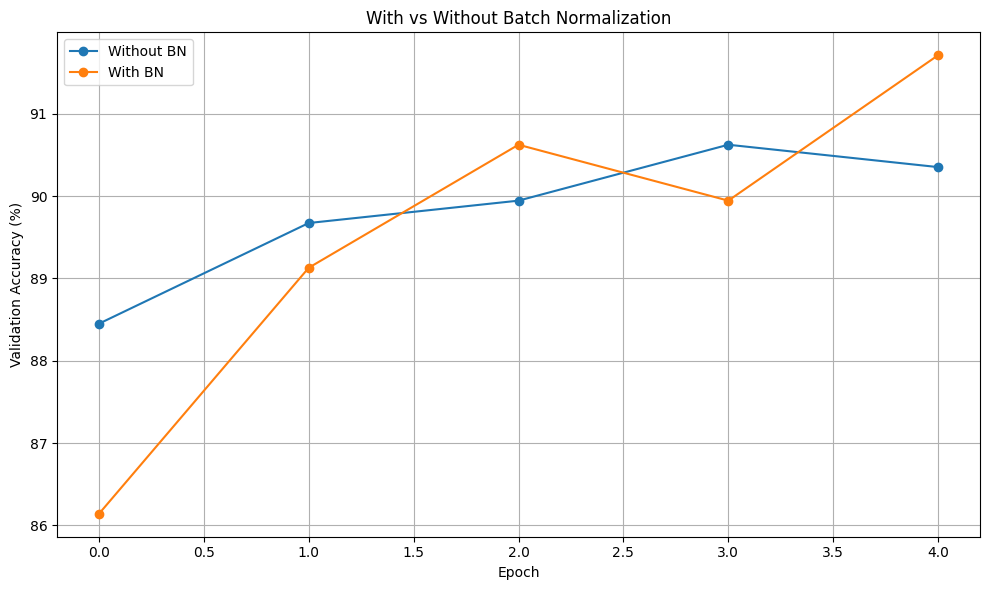

In [31]:
plt.figure(figsize=(10, 6))

for name, history in bn_histories.items():

    plt.plot(
        np.array(history.history["val_accuracy"]) * 100,
        marker="o",
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("With vs Without Batch Normalization")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(
    "Figures/plot_5_batch_normalization.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [32]:
# ============================================================
# PART 7 — OPTIMIZATION ALGORITHMS
# ============================================================

def build_optimizer_model(optimizer):

    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    # Freeze pretrained MobileNetV2
    base_model.trainable = False

    inputs = keras.Input(shape=(224, 224, 3))

    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(
        128,
        activation="relu"
    )(x)

    outputs = layers.Dense(
        37,
        activation="softmax"
    )(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [33]:
optimizers_dict = {

    "SGD": keras.optimizers.SGD(
        learning_rate=0.001
    ),

    "Momentum": keras.optimizers.SGD(
        learning_rate=0.001,
        momentum=0.9
    ),

    "RMSProp": keras.optimizers.RMSprop(
        learning_rate=0.001
    ),

    "Adam": keras.optimizers.Adam(
        learning_rate=0.001
    )
}

print("Optimizers:")
for name in optimizers_dict:
    print("-", name)

Optimizers:
- SGD
- Momentum
- RMSProp
- Adam


In [34]:
optimizer_histories = {}
optimizer_times = {}
optimizer_models = {}

EPOCHS = 5

for name, optimizer in optimizers_dict.items():

    print("\n" + "=" * 60)
    print(f"Training with {name}")
    print("=" * 60)

    model = build_optimizer_model(optimizer)

    start_time = time.time()

    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=EPOCHS,
        verbose=1
    )

    training_time = time.time() - start_time

    optimizer_histories[name] = history
    optimizer_times[name] = training_time
    optimizer_models[name] = model

    print(f"{name} training time: {training_time:.2f} seconds")


Training with SGD
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 100ms/step - accuracy: 0.0299 - loss: 3.7638 - val_accuracy: 0.0421 - val_loss: 3.6834
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.0591 - loss: 3.5547 - val_accuracy: 0.0774 - val_loss: 3.5054
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.1016 - loss: 3.3841 - val_accuracy: 0.1264 - val_loss: 3.3530
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.1596 - loss: 3.2289 - val_accuracy: 0.1780 - val_loss: 3.2096
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.2225 - loss: 3.0794 - val_accuracy: 0.2337 - val_loss: 3.0683
SGD training time: 42.87 seconds

Training with Momentum
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 101ms/step - accuracy: 0.2143 - loss: 3.1823 - val_accuracy: 0.5068 - val_loss: 2.4484
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.6817 - loss: 1.7713 - val_accuracy: 0.7962 - val_loss: 1.2590
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6

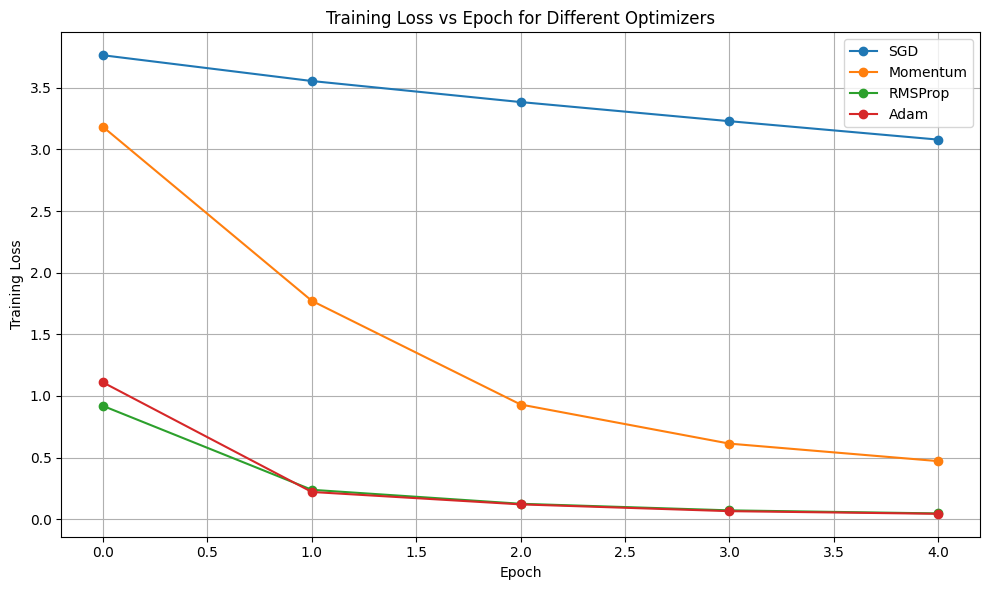

In [35]:
# ============================================================
# Plot 6 — Training Loss vs Epoch
# ============================================================

plt.figure(figsize=(10, 6))

for name, history in optimizer_histories.items():

    plt.plot(
        history.history["loss"],
        marker="o",
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epoch for Different Optimizers")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "Figures/plot_6_optimizer_training_loss.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

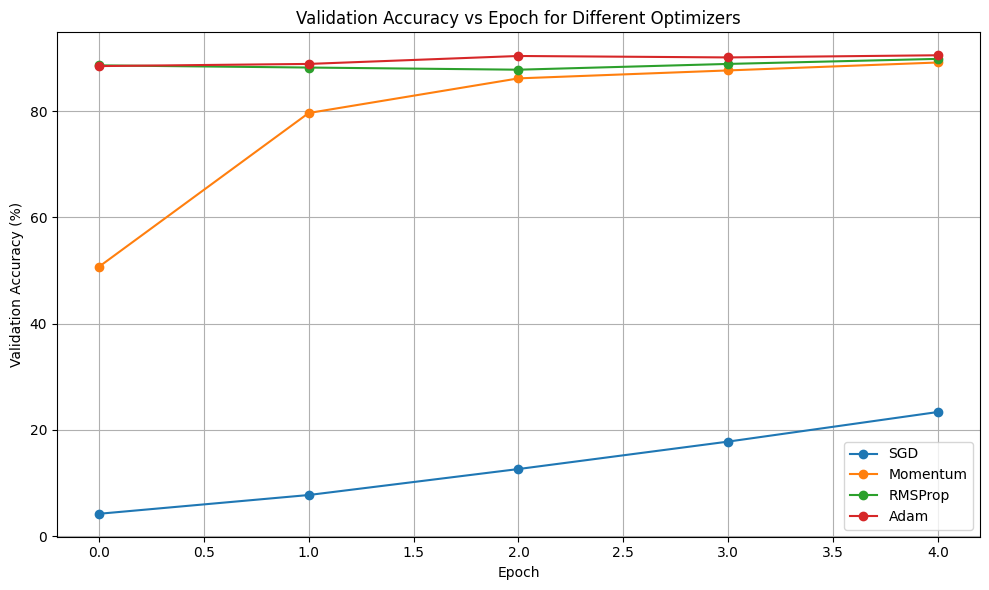

In [36]:
# ============================================================
# Plot 7 — Validation Accuracy vs Epoch
# ============================================================

plt.figure(figsize=(10, 6))

for name, history in optimizer_histories.items():

    val_accuracy = (
        np.array(history.history["val_accuracy"]) * 100
    )

    plt.plot(
        val_accuracy,
        marker="o",
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Validation Accuracy vs Epoch for Different Optimizers")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "Figures/plot_7_optimizer_validation_accuracy.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [37]:
optimizer_results = []

for name, history in optimizer_histories.items():

    train_loss = history.history["loss"]
    val_accuracy = history.history["val_accuracy"]

    best_val_accuracy = max(val_accuracy)

    best_epoch = np.argmax(val_accuracy) + 1

    final_loss = train_loss[-1]

    optimizer_results.append({
        "Optimizer": name,
        "Final Loss": final_loss,
        "Best Validation Accuracy (%)":
            best_val_accuracy * 100,
        "Epoch to Converge": best_epoch,
        "Training Time (s)":
            optimizer_times[name]
    })

optimizer_results_df = pd.DataFrame(
    optimizer_results
)

optimizer_results_df

,Optimizer,Final Loss,Best Validation Accuracy (%),Epoch to Converge,Training Time (s)
0,SGD,3.079395,23.369566,5,42.872424
1,Momentum,0.470831,89.130437,5,42.319794
2,RMSProp,0.046401,89.809781,5,42.349535
3,Adam,0.043456,90.489131,5,42.808264


In [38]:
# ============================================================
# PART 8A — LEARNING RATE TUNING
# ============================================================

def build_learning_rate_model(learning_rate):

    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    base_model.trainable = False

    inputs = keras.Input(shape=(224, 224, 3))

    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(
        128,
        activation="relu"
    )(x)

    x = layers.Dropout(0.25)(x)

    outputs = layers.Dense(
        37,
        activation="softmax"
    )(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [39]:
learning_rates = [0.001, 0.0001]

learning_rate_histories = {}
learning_rate_times = {}
learning_rate_models = {}

EPOCHS = 5

for lr in learning_rates:

    print("\n" + "=" * 60)
    print(f"Learning Rate: {lr}")
    print("=" * 60)

    model = build_learning_rate_model(lr)

    start_time = time.time()

    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=EPOCHS,
        verbose=1
    )

    training_time = time.time() - start_time

    learning_rate_histories[lr] = history
    learning_rate_times[lr] = training_time
    learning_rate_models[lr] = model

    print(f"Training time: {training_time:.2f} seconds")


Learning Rate: 0.001
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 110ms/step - accuracy: 0.6355 - loss: 1.3769 - val_accuracy: 0.8913 - val_loss: 0.4159
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.8859 - loss: 0.3638 - val_accuracy: 0.9049 - val_loss: 0.3279
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.9266 - loss: 0.2359 - val_accuracy: 0.9035 - val_loss: 0.3152
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.9518 - loss: 0.1652 - val_accuracy: 0.9103 - val_loss: 0.2949
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.9660 - loss: 0.1252 - val_accuracy: 0.9144 - val_loss: 0.2884
Training time: 43.85 seconds

Learning Rate: 0.0001
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 100ms/step - accuracy: 0.1790 - loss: 3.1898 - val_accuracy: 0.4497 - val_loss: 2.5599
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.5207 - loss: 2.0747 - val_accuracy: 0.7188 - val_loss: 1.5181
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 

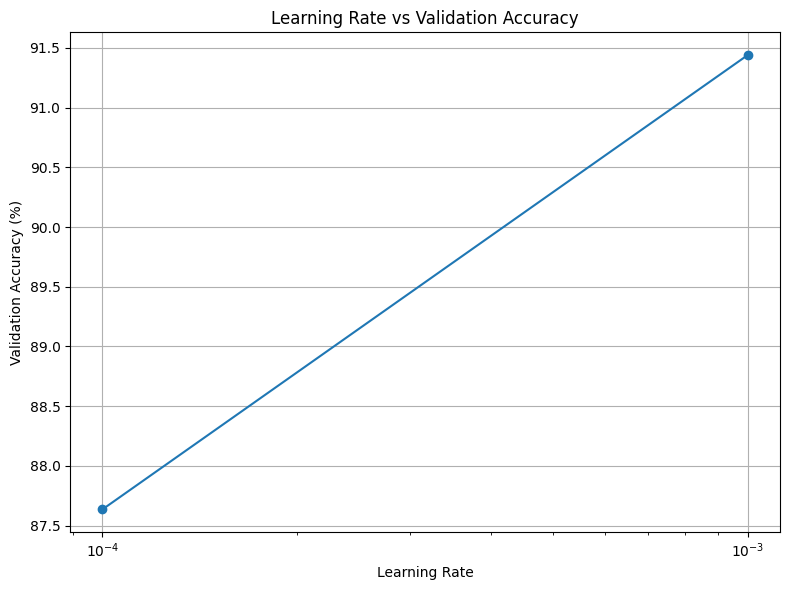

,Learning Rate,Validation Accuracy (%)
0,0.0010,91.440219
1,0.0001,87.635869


In [40]:
# ============================================================
# Plot 8 — Learning Rate vs Validation Accuracy
# ============================================================

learning_rate_values = []
learning_rate_accuracies = []

for lr, history in learning_rate_histories.items():

    learning_rate_values.append(lr)

    learning_rate_accuracies.append(
        max(history.history["val_accuracy"]) * 100
    )

plt.figure(figsize=(8, 6))

plt.plot(
    learning_rate_values,
    learning_rate_accuracies,
    marker="o"
)

plt.xscale("log")

plt.xlabel("Learning Rate")
plt.ylabel("Validation Accuracy (%)")
plt.title("Learning Rate vs Validation Accuracy")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "Figures/plot_8_learning_rate.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

learning_rate_results = pd.DataFrame({
    "Learning Rate": learning_rate_values,
    "Validation Accuracy (%)": learning_rate_accuracies
})

learning_rate_results

In [41]:
# ============================================================
# PART 8B — BATCH SIZE TUNING
# ============================================================

batch_sizes = [16, 32, 64]

batch_train_data = {}
batch_val_data = {}

for batch_size in batch_sizes:

    batch_train_data[batch_size] = train_raw.map(
        preprocess_image,
        num_parallel_calls=tf.data.AUTOTUNE
    ).shuffle(
        1000,
        seed=SEED,
        reshuffle_each_iteration=True
    ).batch(
        batch_size
    ).prefetch(
        tf.data.AUTOTUNE
    )

    batch_val_data[batch_size] = val_raw.map(
        preprocess_image,
        num_parallel_calls=tf.data.AUTOTUNE
    ).batch(
        batch_size
    ).prefetch(
        tf.data.AUTOTUNE
    )

print("Batch-size datasets created.")

Batch-size datasets created.


In [42]:
def build_batch_size_model():

    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    base_model.trainable = False

    inputs = keras.Input(shape=(224, 224, 3))

    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(
        128,
        activation="relu"
    )(x)

    x = layers.Dropout(0.25)(x)

    outputs = layers.Dense(
        37,
        activation="softmax"
    )(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [43]:
batch_size_histories = {}
batch_size_times = {}
batch_size_models = {}

for batch_size in batch_sizes:

    print("\n" + "=" * 60)
    print(f"Batch Size: {batch_size}")
    print("=" * 60)

    model = build_batch_size_model()

    start_time = time.time()

    history = model.fit(
        batch_train_data[batch_size],
        validation_data=batch_val_data[batch_size],
        epochs=EPOCHS,
        verbose=1
    )

    training_time = time.time() - start_time

    batch_size_histories[batch_size] = history
    batch_size_times[batch_size] = training_time
    batch_size_models[batch_size] = model

    print(f"Training time: {training_time:.2f} seconds")


Batch Size: 16
Epoch 1/5


2026-08-24 15:39:19.579367: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-24 15:39:19.716954: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


184/184 ━━━━━━━━━━━━━━━━━━━━ 28s 53ms/step - accuracy: 0.6895 - loss: 1.1399 - val_accuracy: 0.8940 - val_loss: 0.3667
Epoch 2/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.8971 - loss: 0.3337 - val_accuracy: 0.8859 - val_loss: 0.3268
Epoch 3/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.9321 - loss: 0.2118 - val_accuracy: 0.8899 - val_loss: 0.3449
Epoch 4/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.9538 - loss: 0.1398 - val_accuracy: 0.8954 - val_loss: 0.3162
Epoch 5/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.9643 - loss: 0.1071 - val_accuracy: 0.9062 - val_loss: 0.3183
Training time: 52.58 seconds

Batch Size: 32
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 101ms/step - accuracy: 0.6372 - loss: 1.3987 - val_accuracy: 0.8723 - val_loss: 0.4220
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.8804 - loss: 0.3941 - val_accuracy: 0.8859 - val_loss: 0.3571
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.9304 -

2026-08-24 15:40:58.429063: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-24 15:40:58.569104: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


46/46 ━━━━━━━━━━━━━━━━━━━━ 32s 282ms/step - accuracy: 0.5707 - loss: 1.7014 - val_accuracy: 0.8628 - val_loss: 0.4994
Epoch 2/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - accuracy: 0.8699 - loss: 0.4420 - val_accuracy: 0.8927 - val_loss: 0.3729
Epoch 3/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - accuracy: 0.9192 - loss: 0.2729 - val_accuracy: 0.9022 - val_loss: 0.3149
Epoch 4/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - accuracy: 0.9409 - loss: 0.1974 - val_accuracy: 0.9103 - val_loss: 0.2943
Epoch 5/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - accuracy: 0.9613 - loss: 0.1409 - val_accuracy: 0.9130 - val_loss: 0.2719
Training time: 56.38 seconds


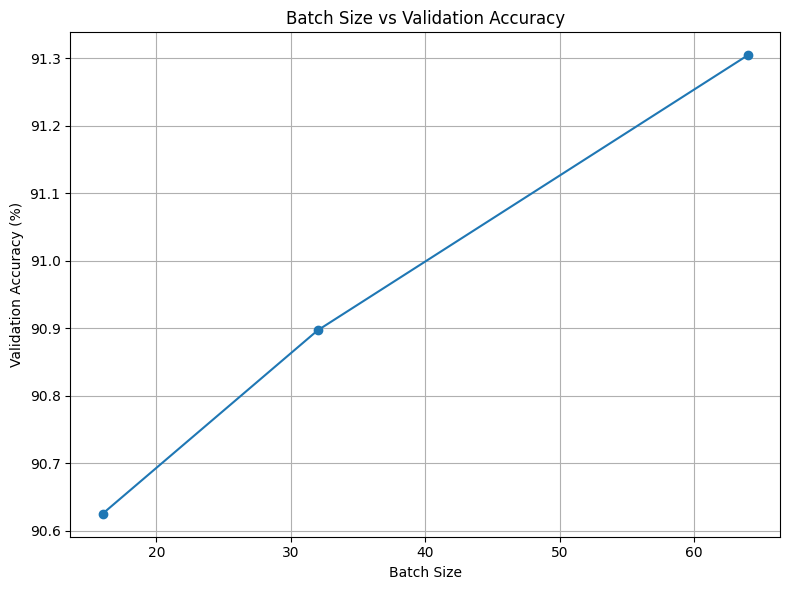

,Batch Size,Validation Accuracy (%)
0,16,90.625000
1,32,90.896738
2,64,91.304350


In [44]:
# ============================================================
# Plot 9 — Batch Size vs Validation Accuracy
# ============================================================

batch_size_accuracies = []

for batch_size in batch_sizes:

    accuracy = max(
        batch_size_histories[batch_size]
        .history["val_accuracy"]
    ) * 100

    batch_size_accuracies.append(accuracy)

plt.figure(figsize=(8, 6))

plt.plot(
    batch_sizes,
    batch_size_accuracies,
    marker="o"
)

plt.xlabel("Batch Size")
plt.ylabel("Validation Accuracy (%)")
plt.title("Batch Size vs Validation Accuracy")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "Figures/plot_9_batch_size.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

batch_size_results = pd.DataFrame({
    "Batch Size": batch_sizes,
    "Validation Accuracy (%)": batch_size_accuracies
})

batch_size_results

In [45]:
# ============================================================
# PART 8C — DROPOUT RATE TUNING
# ============================================================

def build_dropout_model(dropout_rate):

    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    base_model.trainable = False

    inputs = keras.Input(shape=(224, 224, 3))

    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(
        128,
        activation="relu"
    )(x)

    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)

    outputs = layers.Dense(
        37,
        activation="softmax"
    )(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [46]:
dropout_rates = [0, 0.25, 0.5]

dropout_histories = {}
dropout_times = {}
dropout_models = {}

for dropout_rate in dropout_rates:

    print("\n" + "=" * 60)
    print(f"Dropout Rate: {dropout_rate}")
    print("=" * 60)

    model = build_dropout_model(dropout_rate)

    start_time = time.time()

    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=EPOCHS,
        verbose=1
    )

    training_time = time.time() - start_time

    dropout_histories[dropout_rate] = history
    dropout_times[dropout_rate] = training_time
    dropout_models[dropout_rate] = model

    print(f"Training time: {training_time:.2f} seconds")


Dropout Rate: 0
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 99ms/step - accuracy: 0.7296 - loss: 1.0283 - val_accuracy: 0.8601 - val_loss: 0.4531
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.9382 - loss: 0.2094 - val_accuracy: 0.8940 - val_loss: 0.3440
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.9728 - loss: 0.1075 - val_accuracy: 0.8886 - val_loss: 0.3321
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.9918 - loss: 0.0560 - val_accuracy: 0.8927 - val_loss: 0.3218
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.9983 - loss: 0.0319 - val_accuracy: 0.8967 - val_loss: 0.3117
Training time: 42.43 seconds

Dropout Rate: 0.25
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 100ms/step - accuracy: 0.6372 - loss: 1.3999 - val_accuracy: 0.8764 - val_loss: 0.4336
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.8893 - loss: 0.3640 - val_accuracy: 0.8940 - val_loss: 0.3320
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step

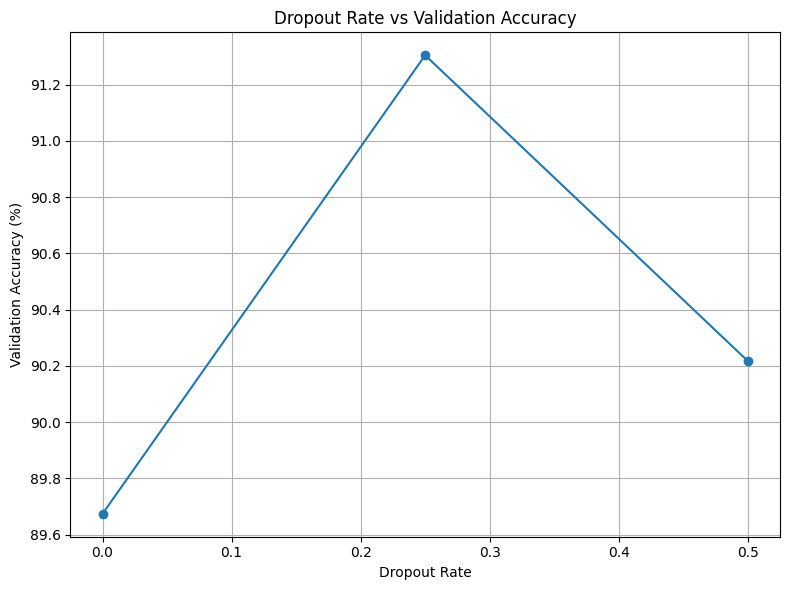

,Dropout Rate,Validation Accuracy (%)
0,0.00,89.673913
1,0.25,91.304350
2,0.50,90.217394


In [47]:
# ============================================================
# Plot 10 — Dropout Rate vs Validation Accuracy
# ============================================================

dropout_accuracies = []

for dropout_rate in dropout_rates:

    accuracy = max(
        dropout_histories[dropout_rate]
        .history["val_accuracy"]
    ) * 100

    dropout_accuracies.append(accuracy)

plt.figure(figsize=(8, 6))

plt.plot(
    dropout_rates,
    dropout_accuracies,
    marker="o"
)

plt.xlabel("Dropout Rate")
plt.ylabel("Validation Accuracy (%)")
plt.title("Dropout Rate vs Validation Accuracy")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "Figures/plot_10_dropout_rate.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

dropout_results = pd.DataFrame({
    "Dropout Rate": dropout_rates,
    "Validation Accuracy (%)": dropout_accuracies
})

dropout_results

In [48]:
# ============================================================
# PART 9 — TRANSFER LEARNING AND FINE-TUNING
# ============================================================

def build_feature_extraction_model():

    # Load ImageNet-pretrained MobileNetV2
    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    # Freeze entire pretrained base
    base_model.trainable = False

    inputs = keras.Input(shape=(224, 224, 3))

    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(
        128,
        activation="relu"
    )(x)

    x = layers.Dropout(0.25)(x)

    outputs = layers.Dense(
        37,
        activation="softmax"
    )(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [49]:
feature_extraction_model = build_feature_extraction_model()

start_time = time.time()

feature_extraction_history = feature_extraction_model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,
    verbose=1
)

feature_extraction_time = time.time() - start_time

print(
    f"Feature extraction training time: "
    f"{feature_extraction_time:.2f} seconds"
)

Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 98ms/step - accuracy: 0.6328 - loss: 1.3956 - val_accuracy: 0.8478 - val_loss: 0.5038
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.8865 - loss: 0.3753 - val_accuracy: 0.8777 - val_loss: 0.3776
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.9260 - loss: 0.2362 - val_accuracy: 0.8954 - val_loss: 0.3175
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.9453 - loss: 0.1860 - val_accuracy: 0.8940 - val_loss: 0.3263
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.9657 - loss: 0.1222 - val_accuracy: 0.8967 - val_loss: 0.3369
Feature extraction training time: 42.67 seconds


In [50]:
def build_fine_tuning_model(
    fine_tune_layers=20,
    learning_rate=1e-5
):

    # Load ImageNet-pretrained MobileNetV2
    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    # Freeze entire base first
    base_model.trainable = True

    # Freeze all layers except the last selected layers
    for layer in base_model.layers[:-fine_tune_layers]:
        layer.trainable = False

    # Keep Batch Normalization layers frozen
    for layer in base_model.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    inputs = keras.Input(shape=(224, 224, 3))

    x = base_model(inputs, training=False)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(
        128,
        activation="relu"
    )(x)

    x = layers.Dropout(0.25)(x)

    outputs = layers.Dense(
        37,
        activation="softmax"
    )(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [51]:
fine_tuning_model = build_fine_tuning_model(
    fine_tune_layers=20,
    learning_rate=1e-5
)

trainable_layers = [
    layer.name
    for layer in fine_tuning_model.layers
    if layer.trainable
]

print("Number of trainable layers:", len(trainable_layers))
print("\nTrainable layers:")

for layer_name in trainable_layers:
    print(layer_name)


start_time = time.time()

fine_tuning_history = fine_tuning_model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,
    verbose=1
)

fine_tuning_time = time.time() - start_time

print(
    f"Fine-tuning training time: "
    f"{fine_tuning_time:.2f} seconds"
)

Number of trainable layers: 6

Trainable layers:
input_layer_49
mobilenetv2_1.00_224
global_average_pooling2d_24
dense_43
dropout_9
dense_44
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 102ms/step - accuracy: 0.0866 - loss: 3.4762 - val_accuracy: 0.2514 - val_loss: 3.0623
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.3244 - loss: 2.6838 - val_accuracy: 0.5543 - val_loss: 2.0706
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.5231 - loss: 1.8738 - val_accuracy: 0.7473 - val_loss: 1.3793
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.6518 - loss: 1.3663 - val_accuracy: 0.7799 - val_loss: 1.0358
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.7255 - loss: 1.0699 - val_accuracy: 0.8288 - val_loss: 0.8160
Fine-tuning training time: 46.17 seconds


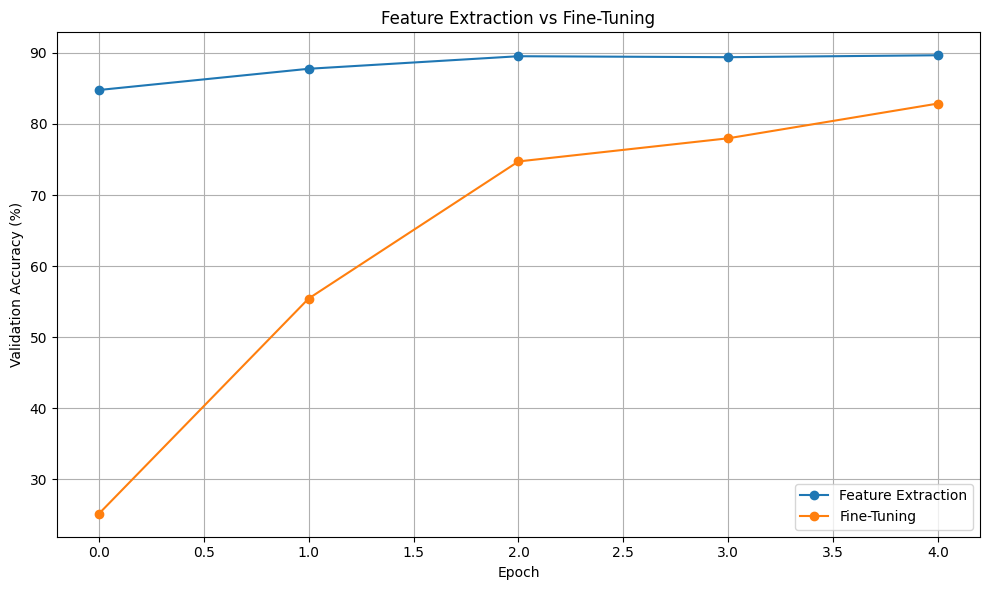

In [52]:
# ============================================================
# Plot 11 — Feature Extraction vs Fine-Tuning
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    np.array(
        feature_extraction_history.history["val_accuracy"]
    ) * 100,
    marker="o",
    label="Feature Extraction"
)

plt.plot(
    np.array(
        fine_tuning_history.history["val_accuracy"]
    ) * 100,
    marker="o",
    label="Fine-Tuning"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Feature Extraction vs Fine-Tuning")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "Figures/plot_11_feature_extraction_vs_finetuning.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

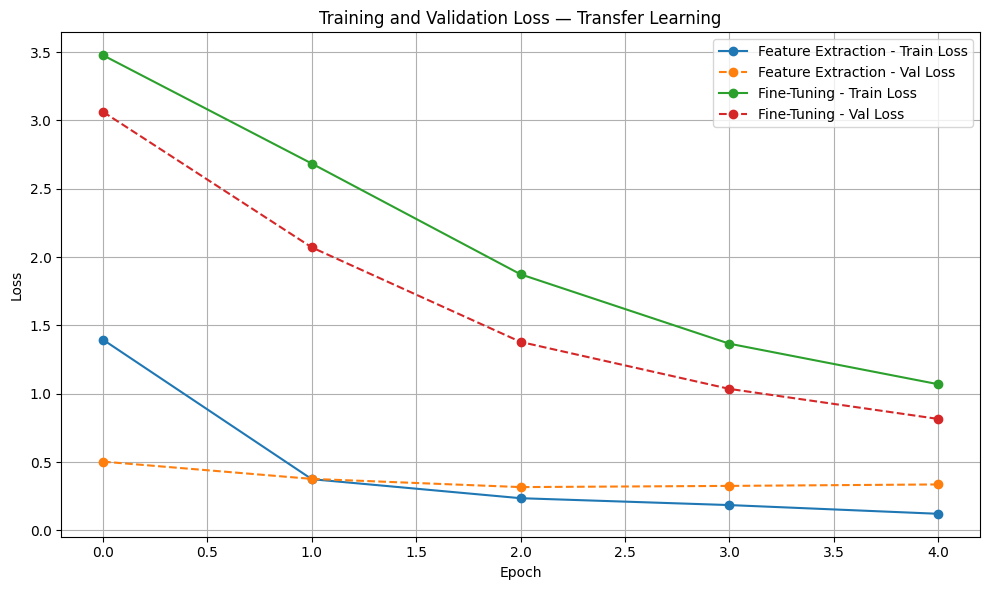

In [53]:
# ============================================================
# Plot 12 — Training and Validation Loss
# ============================================================

plt.figure(figsize=(10, 6))

# Feature extraction
plt.plot(
    feature_extraction_history.history["loss"],
    marker="o",
    label="Feature Extraction - Train Loss"
)

plt.plot(
    feature_extraction_history.history["val_loss"],
    marker="o",
    linestyle="--",
    label="Feature Extraction - Val Loss"
)

# Fine-tuning
plt.plot(
    fine_tuning_history.history["loss"],
    marker="o",
    label="Fine-Tuning - Train Loss"
)

plt.plot(
    fine_tuning_history.history["val_loss"],
    marker="o",
    linestyle="--",
    label="Fine-Tuning - Val Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss — Transfer Learning")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "Figures/plot_12_transfer_learning_loss.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [54]:
transfer_learning_results = pd.DataFrame({
    "Configuration": [
        "Feature Extraction",
        "Fine-Tuning"
    ],
    "Best Validation Accuracy (%)": [
        max(
            feature_extraction_history.history["val_accuracy"]
        ) * 100,

        max(
            fine_tuning_history.history["val_accuracy"]
        ) * 100
    ],
    "Final Validation Loss": [
        feature_extraction_history.history["val_loss"][-1],
        fine_tuning_history.history["val_loss"][-1]
    ],
    "Training Time (s)": [
        feature_extraction_time,
        fine_tuning_time
    ],
    "Parameters": [
        feature_extraction_model.count_params(),
        fine_tuning_model.count_params()
    ]
})

transfer_learning_results

,Configuration,Best Validation Accuracy (%),Final Validation Loss,Training Time (s),Parameters
0,Feature Extraction,89.673913,0.336911,42.665092,2426725
1,Fine-Tuning,82.880437,0.816008,46.170066,2426725
